In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Exploration

In [2]:
#Data load and first visual
ruta_archivo = "../data/benchmark_ai_detection_multimodel_2026.csv"
df = pd.read_csv(ruta_archivo)
df.head()

,id,timestamp,domain_context,source_model,is_ai_generated,text_content,word_count,readability_score,avg_sentence_length,simulated_perplexity,label_confidence
0,de00499a-a413-4d81-b07d-2ce1c54dd27b,2025-01-06 15:39:56,Medical_Diagnosis_Summary,GPT-5_Preview,1,"Furthermore, Clinical diagnosis clinical respi...",22,-48.702045,4.40,18.15,0.8527
1,6b4603c7-21c3-4290-830a-c9bff4cf6842,2025-01-06 18:56:37,Medical_Diagnosis_Summary,Claude-4_Opus,1,It is imperative to note that Diagnosis diagno...,40,-21.040000,5.00,19.08,0.8602
2,98e69cdf-4b68-4606-874f-b97a8775d5d7,2025-01-08 13:19:23,Legal_Contract_Review,Gemini-2_Pro,1,Based on the available data: Liability termina...,31,-8.544651,4.43,24.83,0.9290
3,0d770e65-4657-42da-b571-b71faf062759,2025-01-08 23:50:36,Legal_Contract_Review,GPT-5_Preview,1,"Furthermore, Termination clause statute statut...",34,-55.204902,4.86,16.99,0.8516
4,10b7bbdd-ed0c-4fd0-b183-c2f2735d2687,2025-01-09 11:48:37,Software_Architecture_Doc,Gemini-2_Pro,1,Based on the available data: Security coach jo...,36,46.777000,6.00,12.38,0.8649


## Columns Descriptor

id: Unique identifier for each text sample.  
timestamp: Date and time of the document creation.  
domain_context: The professional field of the text (e.g., Cybersecurity, Medical).  
source_model: The specific creator of the text (Human or specific AI model).  
is_ai_generated: Binary label (0 = Human, 1 = AI). Target variable for classification.  
text_content: The actual text paragraph to be analyzed.  
word_count: Total number of words in the text.  
readability_score: Flesch Reading Ease score (higher = easier to read).  
avg_sentence_length: Average number of words per sentence (proxy for burstiness).  
simulated_perplexity: A statistical estimation of text randomness (AI tends to have lower perplexity).  
label_confidence: The confidence score of the source attribution (simulated).  

The first two columns are metadata generated during the creation of the dataset, so we will not take them into consideration.  
The target variable we want to predict is "is_ai_generated".  
The "source_model" feature should not be used for training, but in this step of the project, could be relevant for exploration.

## Visualizations

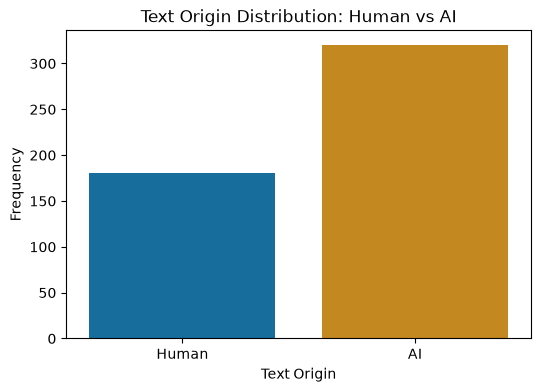

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_ai_generated', hue='is_ai_generated', palette='colorblind', legend=False)

plt.title('Text Origin Distribution: Human vs AI')
plt.xlabel('Text Origin')
plt.ylabel('Frequency')
plt.xticks(ticks=[0, 1], labels=['Human', 'AI'])

plt.show()

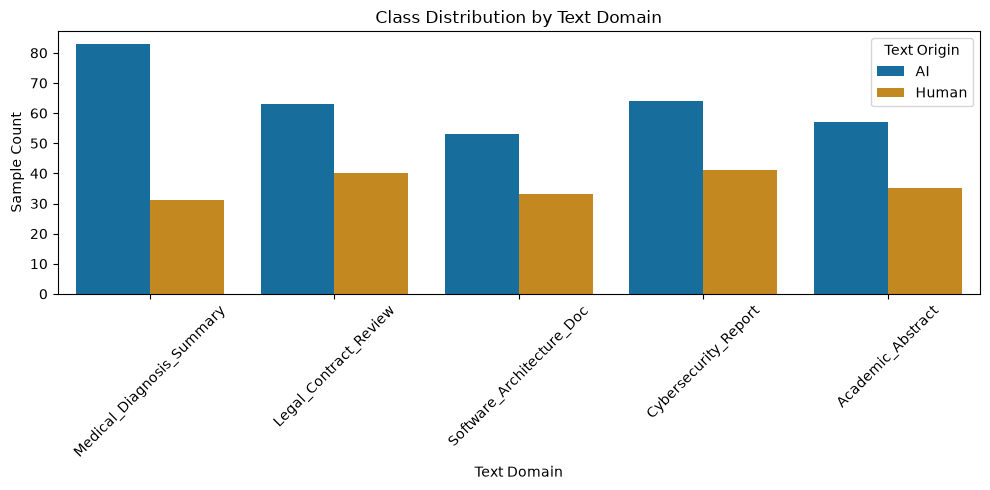

In [4]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='domain_context', 
              hue=df['is_ai_generated'].map({0: 'Human', 1: 'AI'}), 
              palette='colorblind')

plt.title('Class Distribution by Text Domain')
plt.xlabel('Text Domain')
plt.ylabel('Sample Count')
plt.xticks(rotation=45) 
plt.legend(title='Text Origin')
plt.tight_layout() 

plt.show()

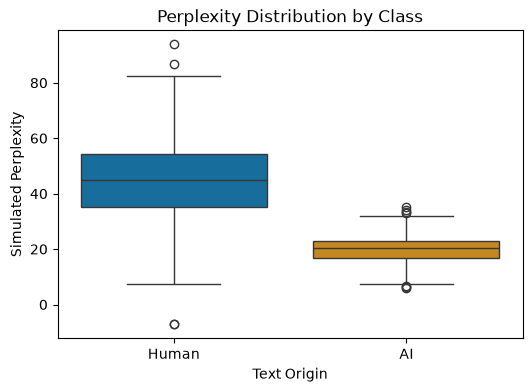

In [5]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='is_ai_generated', y='simulated_perplexity', 
            hue='is_ai_generated', palette='colorblind', legend=False)

plt.title('Perplexity Distribution by Class')
plt.xlabel('Text Origin')
plt.ylabel('Simulated Perplexity')
plt.xticks(ticks=[0, 1], labels=['Human', 'AI'])

plt.show()

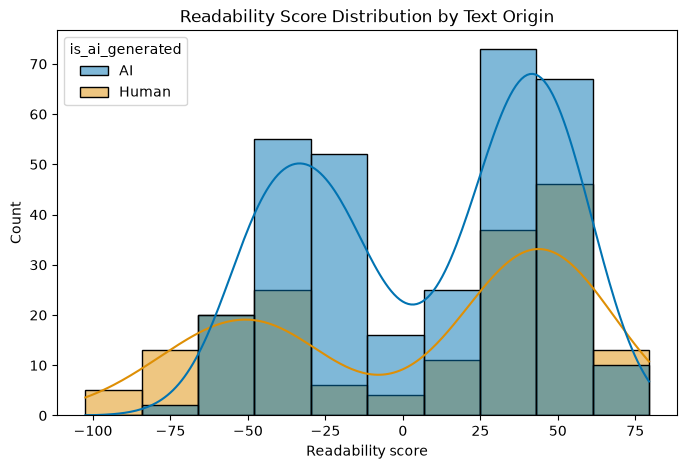

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='readability_score', 
             hue=df['is_ai_generated'].map({0: 'Human', 1: 'AI'}), 
             kde=True, palette='colorblind', alpha=0.5)

plt.title('Readability Score Distribution by Text Origin')
plt.xlabel('Readability score')
plt.ylabel('Count')

plt.show()

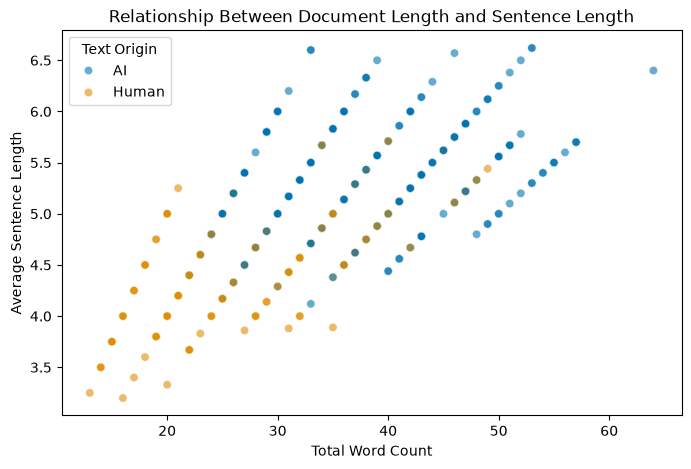

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='word_count', y='avg_sentence_length', 
                hue=df['is_ai_generated'].map({0: 'Human', 1: 'AI'}), 
                alpha=0.6, palette='colorblind')

plt.title('Relationship Between Document Length and Sentence Length')
plt.xlabel('Total Word Count')
plt.ylabel('Average Sentence Length')
plt.legend(title='Text Origin')

plt.show()

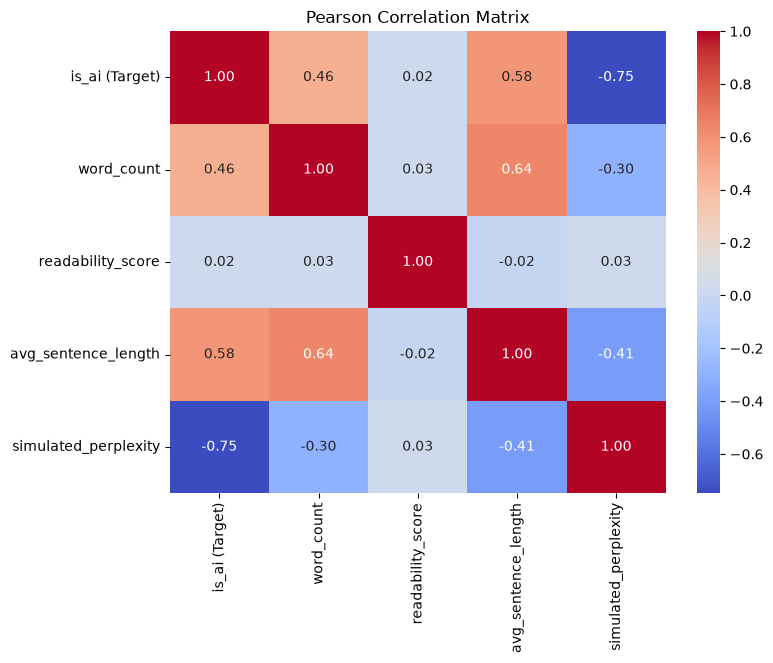

In [8]:
plt.figure(figsize=(8, 6))
numeric_columns = ['is_ai_generated', 'word_count', 'readability_score', 
                   'avg_sentence_length', 'simulated_perplexity']
corr_matrix = df[numeric_columns].corr()

corr_matrix.rename(index={'is_ai_generated': 'is_ai (Target)'}, 
                   columns={'is_ai_generated': 'is_ai (Target)'}, inplace=True)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Matrix')

plt.show()

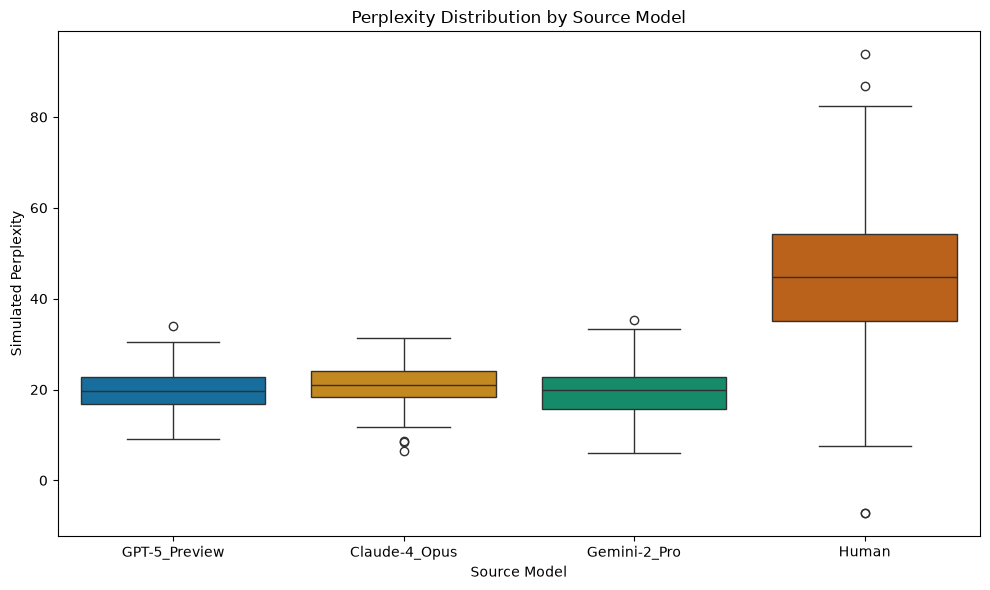

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='source_model', y='simulated_perplexity', 
            hue='source_model', palette='colorblind', legend=False)

plt.title('Perplexity Distribution by Source Model')
plt.xlabel('Source Model')
plt.ylabel('Simulated Perplexity')
plt.tight_layout()

plt.show()

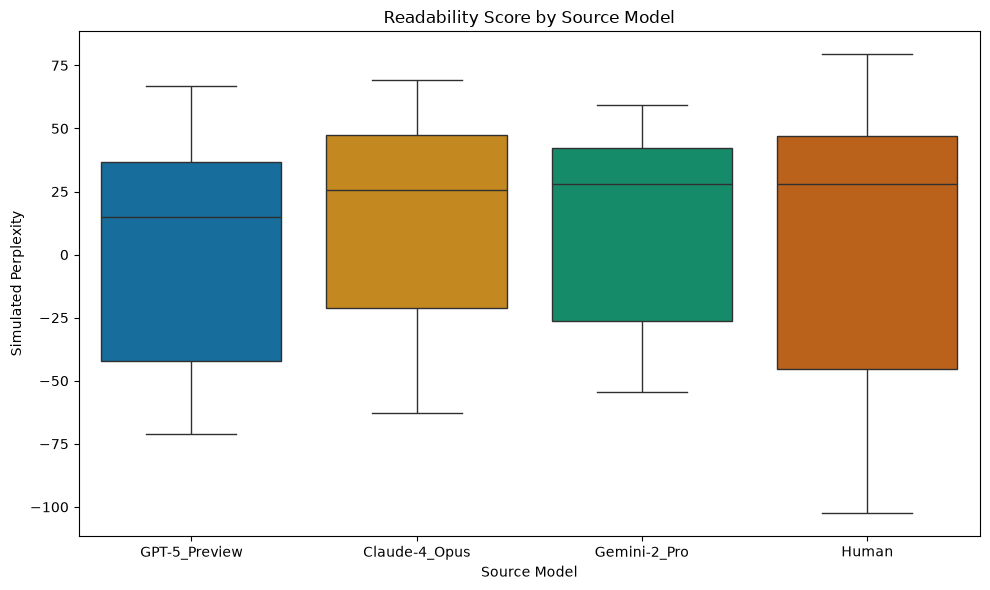

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='source_model', y='readability_score', 
            hue='source_model', palette='colorblind', legend=False)

plt.title('Readability Score by Source Model')
plt.xlabel('Source Model')
plt.ylabel('Simulated Perplexity')
plt.tight_layout()

plt.show()

## Resumen

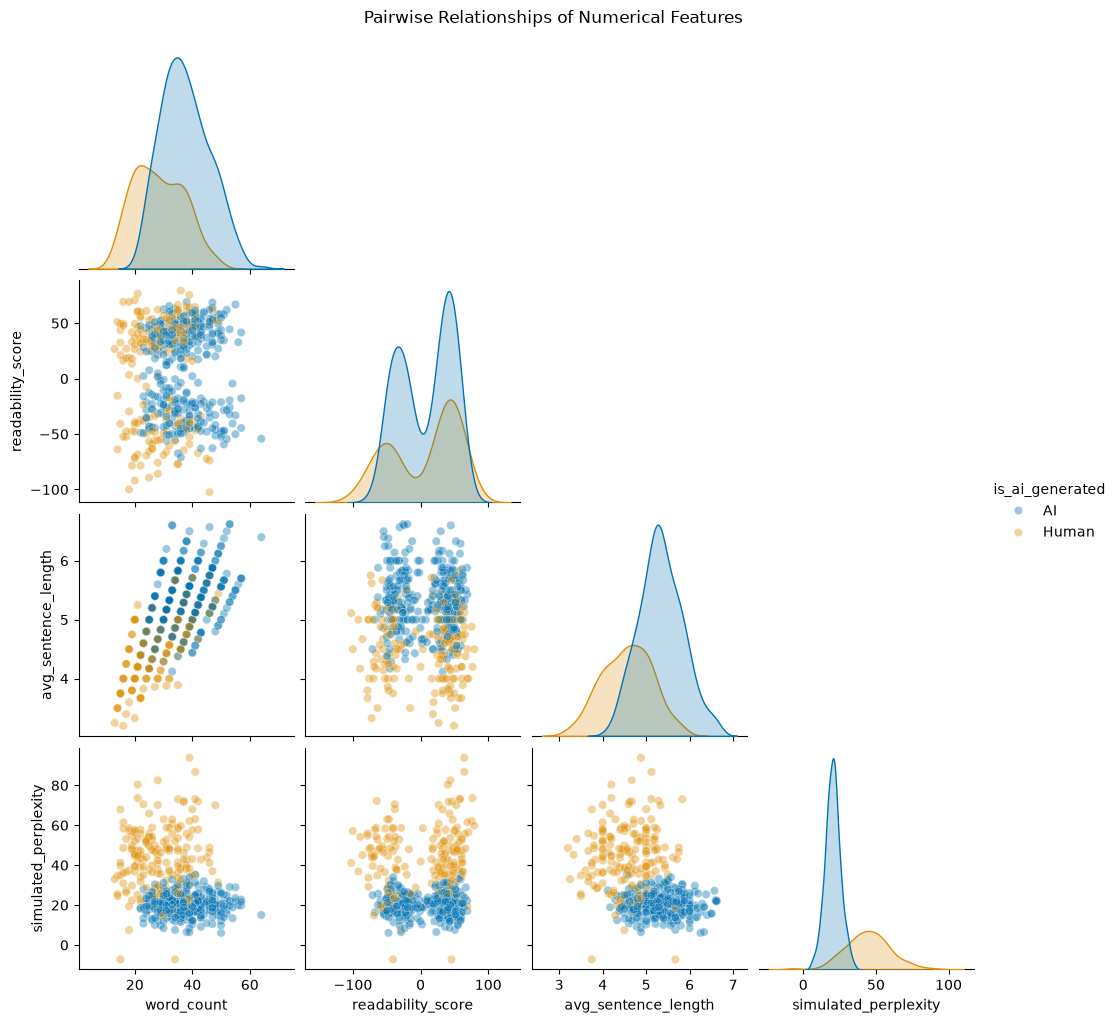

In [11]:
numeric_columns = ['is_ai_generated', 'word_count', 'readability_score', 
                   'avg_sentence_length', 'simulated_perplexity']

df_pair = df[numeric_columns].copy()
df_pair['is_ai_generated'] = df_pair['is_ai_generated'].map({0: 'Human', 1: 'AI'})

sns.pairplot(df_pair, hue='is_ai_generated', palette='colorblind', corner=True,plot_kws={'alpha':0.4})

plt.suptitle('Pairwise Relationships of Numerical Features', y=1.02)

plt.show()

<Figure size 1000x800 with 0 Axes>

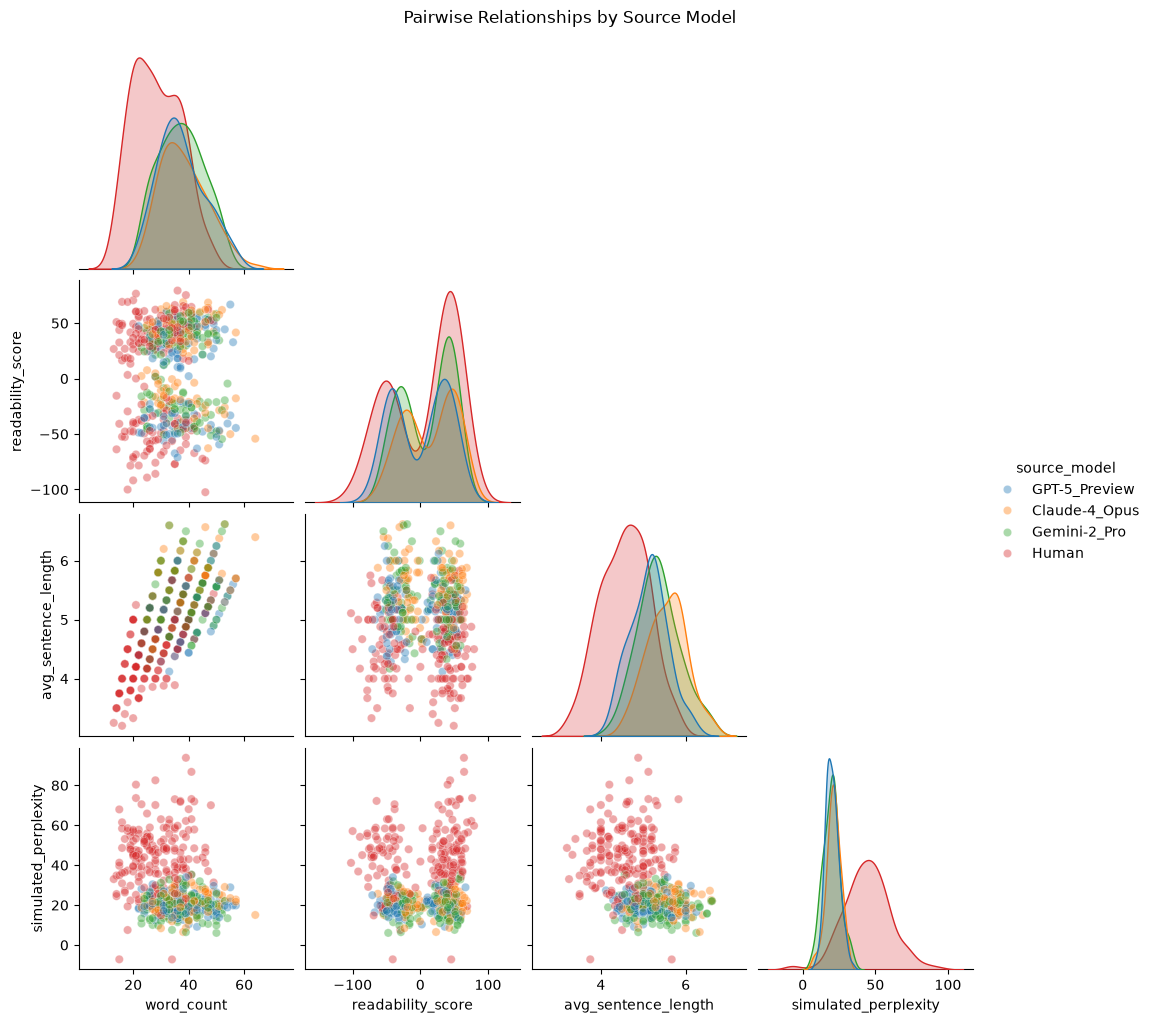

In [12]:
plt.figure(figsize=(10, 8))

columnas_pairplot = ['source_model', 'word_count', 'readability_score', 
                     'avg_sentence_length', 'simulated_perplexity']

df_pair_model = df[columnas_pairplot].copy()
sns.pairplot(df_pair_model, hue='source_model', palette='tab10', corner=True, plot_kws={'alpha':0.4})
plt.suptitle('Pairwise Relationships by Source Model', y=1.02)

plt.show()